# 01 — Corpus Stats

Characterize the phase-1 corpus built by `scripts/build_corpus.py`: composition, size, token estimates, and a couple of sanity checks. Exploration only — the corpus itself is built by the script, not here.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "../src")

ROOT = Path("..")
CLEAN_DIR = ROOT / "data" / "clean"

manifest = json.loads((CLEAN_DIR / "manifest.json").read_text())
df = pd.DataFrame(manifest)
df.head()

,type,slug,title,author,source_url,gutenberg_id,license,split,path,raw_sha256,chars,words,paragraphs_kept,paragraphs_deduped,n_entries,name,source,n_stories
0,book,marcus-aurelius-meditations,Meditations,"Marcus Aurelius, Emperor of Rome",https://www.gutenberg.org/cache/epub/2680/pg26...,2680.0,Public domain (Project Gutenberg),train,books/marcus-aurelius-meditations.txt,3ac9648961664c99e8bafe46224e16b08c1e67c9cb5f4c...,404982,71957,1.0,0.0,NaN,NaN,NaN,NaN
1,book,seneca-minor-dialogues-together-with-the-dialogue,"Minor Dialogues, Together With the Dialogue on...","Seneca, Lucius Annaeus",https://www.gutenberg.org/cache/epub/64576/pg6...,64576.0,Public domain (Project Gutenberg),train,books/seneca-minor-dialogues-together-with-the...,ff92ddd84505a319d6346113900312315ab58e0ff46570...,837274,150542,1.0,0.0,NaN,NaN,NaN,NaN
2,book,epictetus-a-selection-from-the-discourses-of-e...,A Selection from the Discourses of Epictetus w...,Epictetus,https://www.gutenberg.org/cache/epub/10661/pg1...,10661.0,Public domain (Project Gutenberg),train,books/epictetus-a-selection-from-the-discourse...,7915eac7442daed1fbc461b8a281ecc315c5e619126d50...,331103,61838,1.0,0.0,NaN,NaN,NaN,NaN
3,book,laozi-the-tao-teh-king-or-the-tao-and-its-char...,"The Tao Teh King, or the Tao and its Character...",Laozi,https://www.gutenberg.org/cache/epub/216/pg216...,216.0,Public domain (Project Gutenberg),train,books/laozi-the-tao-teh-king-or-the-tao-and-it...,041568f8dfef3ac6c2deb7699756f9d26d6aa8669647f4...,59933,10661,1.0,0.0,NaN,NaN,NaN,NaN
4,book,confucius-the-analects-of-confucius-from-the-c...,The Analects of Confucius (from the Chinese Cl...,Confucius,https://www.gutenberg.org/cache/epub/3330/pg33...,3330.0,Public domain (Project Gutenberg),train,books/confucius-the-analects-of-confucius-from...,ea6d381842afaa2dc2f0665b8007e9d6fd47081afada9b...,165671,29312,1.0,0.0,NaN,NaN,NaN,NaN


## 1. Composition by source type

Books (112 works, mostly classical/Enlightenment philosophy — see `configs/corpus.yaml` for
the full list and `docs/DECISIONS.md` D-011 for how they were picked), GCIDE dictionary
(Webster's 1913 base + WordNet, per D-003), and an optional TinyStories supplement (D-006).

In [2]:
by_type = df.groupby("type", dropna=False).agg(
    files=("path", "count"),
    chars=("chars", "sum"),
    words=("words", "sum"),
).reset_index()
by_type["est_tokens_chars_over_4"] = by_type["chars"] // 4
by_type.loc[len(by_type)] = [
    "TOTAL",
    by_type["files"].sum(),
    by_type["chars"].sum(),
    by_type["words"].sum(),
    by_type["est_tokens_chars_over_4"].sum(),
]
by_type

,type,files,chars,words,est_tokens_chars_over_4
0,book,112,59729479,10220382,14932369
1,dictionary,2,11763935,1836954,2940983
2,supplement,1,1899973203,371713604,474993300
3,TOTAL,115,1971466617,383770940,492866652


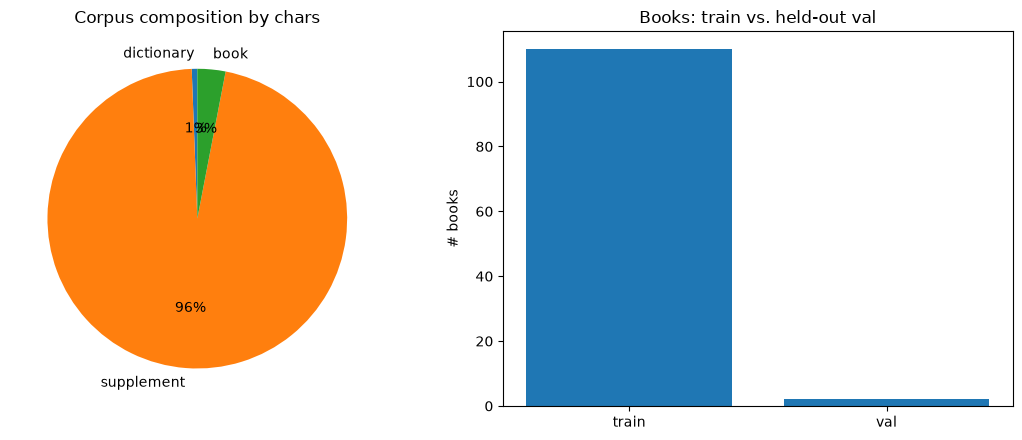

In [3]:
book_df = df[df["type"] == "book"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

pie_data = df[df["type"] != "book"].groupby("type")["chars"].sum()
pie_data["book"] = book_df["chars"].sum()
axes[0].pie(pie_data.values, labels=pie_data.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("Corpus composition by chars")

split_counts = book_df["split"].value_counts()
axes[1].bar(split_counts.index, split_counts.values)
axes[1].set_title("Books: train vs. held-out val")
axes[1].set_ylabel("# books")

plt.tight_layout()
plt.show()

## 2. Token estimate calibration: chars/4 vs. a real tokenizer

`chars/4` is the standard rough-and-ready estimate for English. Calibrate it against GPT-2's
actual BPE tokenizer on a sample of the corpus — this also previews phase 2 (we'll build our
own tokenizer, but GPT-2's is a reasonable reference point for "roughly how many tokens will
this text become").

In [4]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# Sample a handful of books + the dictionary prose rather than tokenizing the
# whole corpus (BPE tokenization of 60MB+ of text is slow and unnecessary for
# a calibration ratio).
import random

random.seed(42)
sample_paths = random.sample(list(book_df["path"]), k=min(15, len(book_df)))
sample_paths.append("dictionary_prose.txt")

sample_chars, sample_tokens = 0, 0
for rel_path in sample_paths:
    text = (CLEAN_DIR / rel_path).read_text(encoding="utf-8")
    sample_chars += len(text)
    sample_tokens += len(tokenizer.encode(text))

chars_per_token = sample_chars / sample_tokens
print(f"sample: {sample_chars:,} chars -> {sample_tokens:,} GPT-2 tokens ({chars_per_token:.2f} chars/token)")

total_chars = int(by_type.loc[by_type["type"] == "TOTAL", "chars"].iloc[0])
print(f"chars/4 estimate:        {total_chars // 4:>12,} tokens")
print(f"GPT-2-calibrated estimate: {int(total_chars / chars_per_token):>10,} tokens")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (57006 > 1024). Running this sequence through the model will result in indexing errors


sample: 19,017,842 chars -> 5,138,036 GPT-2 tokens (3.70 chars/token)
chars/4 estimate:         492,866,654 tokens
GPT-2-calibrated estimate: 532,629,645 tokens


## 3. Book length distribution

How lopsided is the corpus? A few very long works (Montaigne's complete essays, Plutarch's
Lives) sit alongside short dialogues (Plato's *Crito*, Voltaire's *Micromegas*).

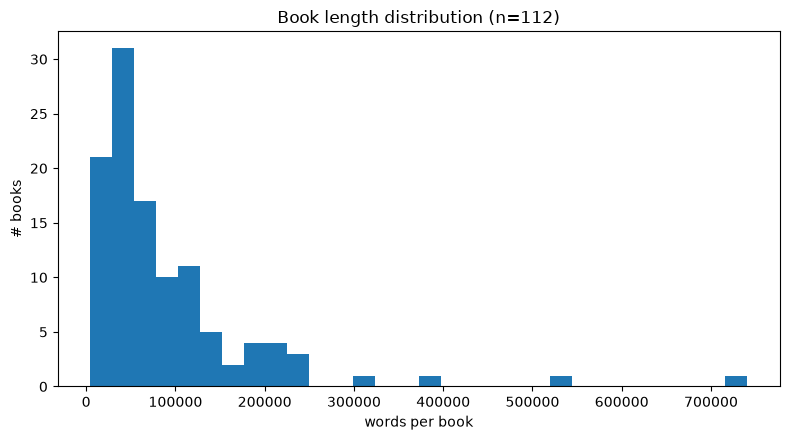

Longest 5 books:
                                                         title               author  words
              Plutarch: Lives of the noble Grecians and Romans             Plutarch 740514
                      Essays of Michel de Montaigne — Complete Montaigne, Michel de 525864
An Inquiry into the Nature and Causes of the Wealth of Nations          Smith, Adam 381076
              The Life of Reason: The Phases of Human Progress    Santayana, George 317273
                                                          Laws                Plato 238601

Shortest 5 books:
                                               title           author  words
                       The Right to Ignore the State Spencer, Herbert   4807
                                         The Apology         Xenophon   4814
                                               Crito            Plato   6584
                                          Micromegas         Voltaire   7724
The Tao Teh King, or the Tao and 

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(book_df["words"], bins=30)
ax.set_xlabel("words per book")
ax.set_ylabel("# books")
ax.set_title(f"Book length distribution (n={len(book_df)})")
plt.tight_layout()
plt.show()

print("Longest 5 books:")
print(book_df.nlargest(5, "words")[["title", "author", "words"]].to_string(index=False))
print("\nShortest 5 books:")
print(book_df.nsmallest(5, "words")[["title", "author", "words"]].to_string(index=False))

## 4. Most-common-words sanity check

A cheap smoke test: the most frequent words in a corpus this size should be ordinary function
words (`the`, `of`, `and`, ...), not encoding artifacts, boilerplate, or a single repeated
token — the latter would mean cleaning or dedup silently failed somewhere.

In [6]:
import re

word_re = re.compile(r"[A-Za-z']+")
counts = Counter()
for rel_path in random.sample(list(book_df["path"]), k=min(25, len(book_df))):
    text = (CLEAN_DIR / rel_path).read_text(encoding="utf-8").lower()
    counts.update(word_re.findall(text))

common = pd.DataFrame(counts.most_common(25), columns=["word", "count"])
common

,word,count
0,the,100468
1,of,74593
2,and,54514
3,to,49747
4,is,32770
5,in,32756
6,a,31047
7,that,26516
8,it,22177
9,be,17149


## Learning checkpoints (phase 1)

- **Why dedup matters**: repeated paragraphs (running headers, captions) waste training signal
  and, worse, can leak into the val split if dedup runs *after* splitting rather than before —
  this pipeline dedups within each document before any split happens.
- **Why split by document, not by line**: a random line-level split lets the model see 90% of
  a paragraph in training and memorize the rest in "val" — it looks like generalization but
  isn't. Held-out books/dictionary-entries here are whole, untouched documents.
- **Chars-per-token intuition**: compare the `chars/4` rule of thumb above to GPT-2's actual
  ratio on this corpus — BPE token length depends on vocabulary and text domain (dense
  philosophical prose vs. dictionary definitions tokenize differently).
- **Data quality/mixing vs. architecture**: this notebook is entirely about the data side of
  the project, before a single model parameter exists — worth noticing that.